<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/Lesson_6_ml_basic_assignment_Oluchi_Okoro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TASK 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# TASK 2: LOAD CALIFORNIA HOUSING DATASET

housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# TASK 3: QUICK CHECK OF DATA
# Display first five rows
print("First Five Rows:")
display(df.head())

# Dataset information
print("\nDataset Information:")
df.info()

# Feature names
print("\nFeatures:")
print(housing.feature_names)

# Target variable
print("\nTarget Variable:")
print("MedHouseVal")

print("\nAll variables are numerical (continuous).")

First Five Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target Variable:
MedHouseVal

All variables are numerical (continuous).


In [4]:
# TASK 4: CHECK FOR MISSING VALUES

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
# TASK 5: DESCRIPTIVE STATISTICS
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


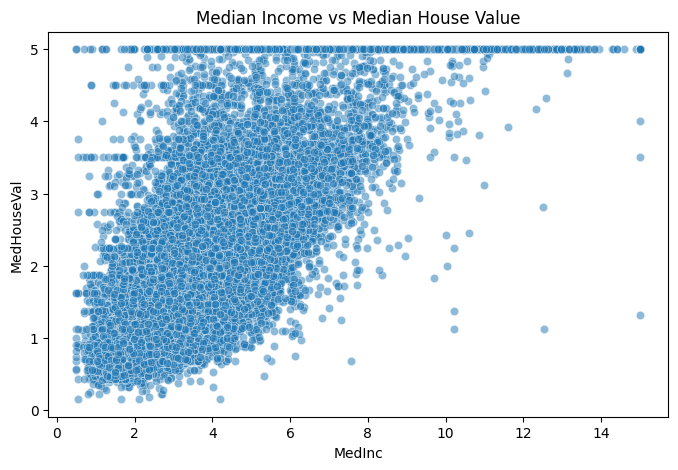

In [6]:
# TASK 6: VISUALIZE FEATURE VS TARGET

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='MedInc',
    y='MedHouseVal',
    alpha=0.5
)

plt.title('Median Income vs Median House Value')
plt.show()

In [7]:
# TASK 7: FUNCTION FOR AUTOMATIC SCATTER PLOTS
def plot_feature_vs_target(data, target):
    """
    Creates scatter plots for all features
    against the target variable.
    """

    features = [col for col in data.columns if col != target]

    for feature in features:

        plt.figure(figsize=(6,4))

        sns.scatterplot(
            x=data[feature],
            y=data[target],
            alpha=0.4
        )

        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')

        plt.show()

print("Function created successfully!")

Function created successfully!


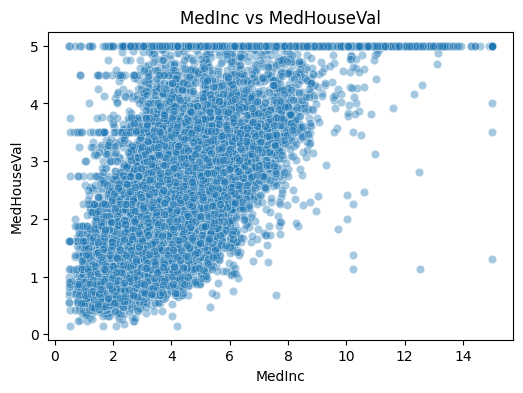

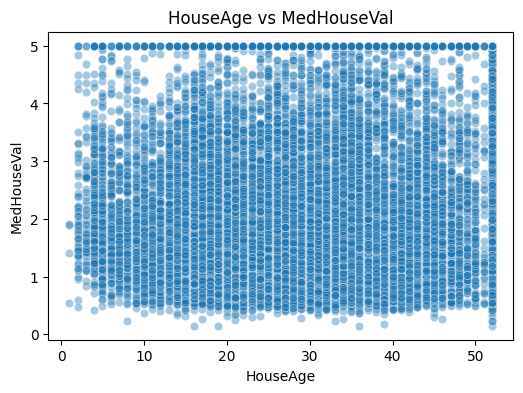

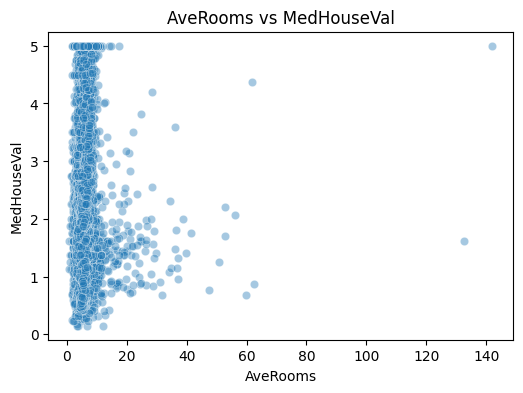

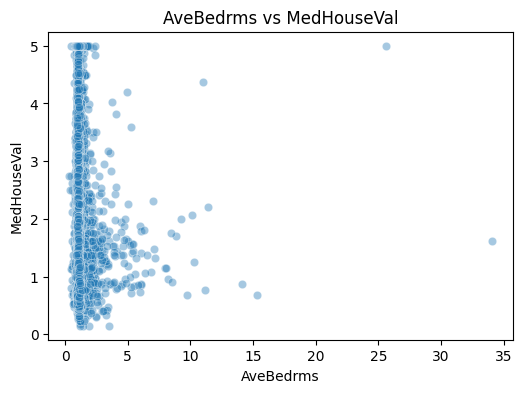

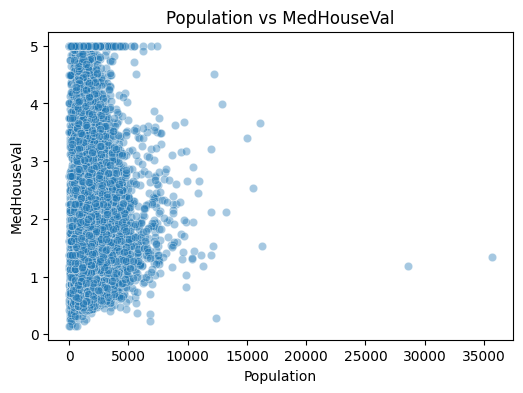

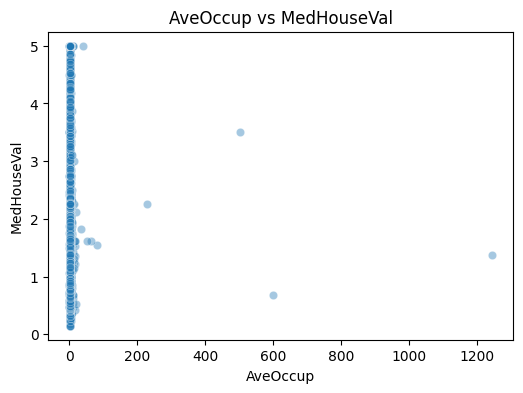

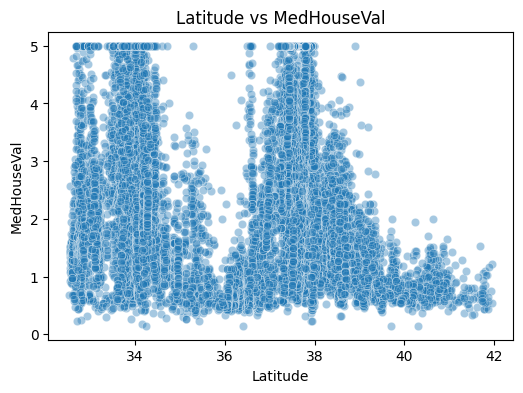

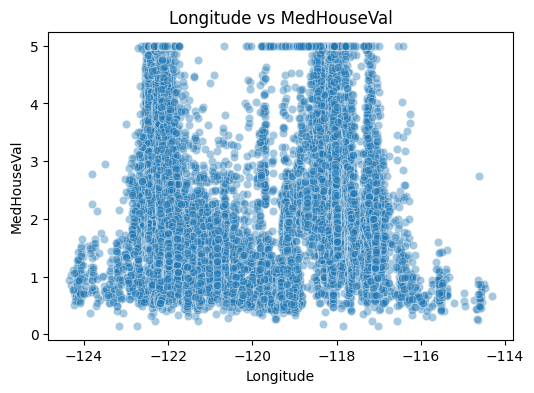

In [8]:
# TASK 8: USE FUNCTION
plot_feature_vs_target(df, 'MedHouseVal')

In [9]:
# TASK 9: TRAIN-TEST SPLIT

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [10]:
# TASK 10: TRAIN REGRESSION MODEL
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
# TASK 11: MODEL EVALUATION
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------")
print("RMSE:", round(rmse, 4))
print("R-Squared:", round(r2, 4))

Model Performance
-------------------
RMSE: 0.7456
R-Squared: 0.5758


In [12]:
# TASK 12: ACTUAL VS PREDICTED VALUES

results = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10]
})

display(results)

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


In [13]:
# TASK 13: PREDICT HOUSE VALUE FOR NEW DATA
new_house = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [25],
    'AveRooms': [6],
    'AveBedrms': [1],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34.0],
    'Longitude': [-118.0]
})

prediction = model.predict(new_house)

print("Predicted Median House Value:")
print(prediction[0])

Predicted Median House Value:
2.398406675742045


In [14]:
# TASK 14: CONCLUSION

print("""
Conclusion:

The California Housing dataset was successfully loaded and analyzed.
Exploratory Data Analysis showed relationships between housing features
and median house values. A Linear Regression model was trained and
evaluated using RMSE and R-squared metrics. The model was then used
to predict house values for new housing data.
""")


Conclusion:

The California Housing dataset was successfully loaded and analyzed.
Exploratory Data Analysis showed relationships between housing features
and median house values. A Linear Regression model was trained and
evaluated using RMSE and R-squared metrics. The model was then used
to predict house values for new housing data.

